# Three Grids, 2019–2025 — Monthly GWh/Day

**One Sensor, One Year — Cross-Edition**

Put all three editions on one chart for the first time: **US-48, Texas (ERCOT), India** from 2019-01 through 2025-12. One metric (total generation, monthly mean GWh/day), one log y-axis, one moving x-axis, three lines.

**Why log scale:** absolute magnitudes differ by >10× (US ≈ 11,700 GWh/day, India ≈ 4,400 GWh/day, Texas ≈ 1,350 GWh/day in 2025). Linear axis would squash Texas into the floor. Log keeps all three readable and makes *growth rates* visually comparable — parallel lines mean same growth %.

**Data coverage:**
- US-48: EIA-930 v2 (from `../../editions/us-grid/data/processed/us48_YYYY_daily.csv`, years 2019–2025 from N01+N01b)
- Texas: ERCOT Fuel Mix (from `../../editions/texas-grid/data/processed/texas_YYYY_daily.csv`, 2019–2025 from N01+N01b)
- India: CEA daily via Robbie Andrew's index (from `../../editions/india-breathes/data/processed/india_all_years.csv`)

India's `total` column has NaN-propagation on pre-2022 days where renewables weren't reported. We recompute a robust total as `thermal + nuclear + hydro + renewables` (all reliably populated).

**Outputs:**
- `../data/three_grids_monthly.csv` — long-format monthly GWh/day
- `../art/three_grids_monthly_static.png` — publication chart
- `../art/three_grids_monthly.gif` — 84-frame growing-line animation

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.animation import FuncAnimation, PillowWriter

REPO = Path('../..')
US_DIR    = REPO / 'editions/us-grid/data/processed'
TX_DIR    = REPO / 'editions/texas-grid/data/processed'
IN_FILE   = REPO / 'editions/india-breathes/data/processed/india_all_years.csv'

OUT_DATA = Path('../data')
OUT_ART = Path('../art')
OUT_DATA.mkdir(parents=True, exist_ok=True)
OUT_ART.mkdir(parents=True, exist_ok=True)

YEARS = [2019, 2020, 2021, 2022, 2023, 2024, 2025]
START, END = '2019-01-01', '2025-12-31'

# Earth & Sky palette picks
COLORS = {'US-48': '#E07A5F', 'Texas': '#F2CC8F', 'India': '#81B29A'}

# Dark mode (matches Ed2 style)
BG = '#0E1017'
FG = '#E5E7EB'
MUTED = '#9CA3AF'

## 1. Load + normalize each region to daily GWh

Three files, three unit conventions, one output table: `date` × `gwh` per region.

In [2]:
# US-48 — hourly MWh per fuel, daily CSV has one row per day per fuel code
# Sum across all non-storage fuel columns, divide by 1000 -> GWh/day
STORAGE_CODES = {'BAT', 'PS', 'OES', 'UES'}
us_frames = []
for y in YEARS:
    p = US_DIR / f'us48_{y}_daily.csv'
    if not p.exists():
        print(f'  US {y}: missing, skipping')
        continue
    d = pd.read_csv(p, parse_dates=['date'], index_col='date')
    gen_cols = [c for c in d.columns if c not in STORAGE_CODES]
    daily = d[gen_cols].sum(axis=1) / 1e3  # MWh/day -> GWh/day
    us_frames.append(daily)
us_daily = pd.concat(us_frames).sort_index()
us_daily.name = 'US-48'
print(f'US-48: {len(us_daily)} days, {us_daily.index.min().date()} → {us_daily.index.max().date()}, mean {us_daily.mean():.0f} GWh/day')

# Texas — ERCOT daily CSV has `total` column (MWh/day)
tx_frames = []
for y in YEARS:
    p = TX_DIR / f'texas_{y}_daily.csv'
    if not p.exists():
        print(f'  Texas {y}: missing, skipping')
        continue
    d = pd.read_csv(p, parse_dates=['Date'], index_col='Date')
    daily = d['total'] / 1e3
    tx_frames.append(daily)
tx_daily = pd.concat(tx_frames).sort_index()
tx_daily.name = 'Texas'
print(f'Texas: {len(tx_daily)} days, {tx_daily.index.min().date()} → {tx_daily.index.max().date()}, mean {tx_daily.mean():.0f} GWh/day')

# India — daily CSV spans 2018-04 to 2026-03. Native unit is MU (= GWh).
# Use thermal+nuclear+hydro+bhutan+renewables. Pre-2022 some days have wind/solar NaN (fill 0),
# but CEA dropped thermal/hydro/nuclear entirely on ~74 days during Mar-May 2020 COVID lockdown —
# those look like 200-400 GWh/day, non-physical. Mask days where `thermal` is NaN (load-bearing column).
d_in = pd.read_csv(IN_FILE, parse_dates=['date'], index_col='date').sort_index()
d_in = d_in.loc[START:END]
robust_cols = [c for c in ['thermal', 'nuclear', 'hydro', 'bhutan', 'renewables'] if c in d_in.columns]
in_daily = d_in[robust_cols].fillna(0).sum(axis=1)
in_daily = in_daily.mask(d_in['thermal'].isna())  # drop source-gap days
in_daily.name = 'India'
valid_days = in_daily.notna().sum()
print(f'India: {len(in_daily)} total days, {valid_days} valid ({valid_days/len(in_daily)*100:.1f}%), mean {in_daily.mean():.0f} GWh/day')

US-48: 2557 days, 2019-01-01 → 2025-12-31, mean 11059 GWh/day
Texas: 2557 days, 2019-01-01 → 2025-12-31, mean 1169 GWh/day
India: 2557 total days, 2483 valid (97.1%), mean 4296 GWh/day


## 2. Aggregate to monthly mean GWh/day

`resample('MS').mean()` gives one row per calendar month, indexed at the first of the month. 84 months × 3 regions = 252 rows.

In [3]:
def monthly_mean(daily_series, min_days=10):
    """Monthly mean GWh/day, but NaN if fewer than `min_days` non-NaN days in that month."""
    monthly = daily_series.resample('MS').mean()
    valid_count = daily_series.resample('MS').count()
    monthly = monthly.where(valid_count >= min_days)
    return monthly

us_m = monthly_mean(us_daily)
tx_m = monthly_mean(tx_daily)
in_m = monthly_mean(in_daily)

# Align and stack
monthly = pd.DataFrame({'US-48': us_m, 'Texas': tx_m, 'India': in_m})
monthly = monthly.loc['2019-01-01':'2025-12-01']
print(f'Monthly frame: {monthly.shape[0]} months × {monthly.shape[1]} regions')
print(f'NaN count per region: {monthly.isna().sum().to_dict()}')
if monthly.isna().any().any():
    gaps = monthly[monthly.isna().any(axis=1)].index.strftime('%Y-%m').tolist()
    print(f'Months with gaps (insufficient source data): {gaps}')

# Interpolate NaN gaps linearly so animation lines stay continuous; keep source CSV raw.
monthly_plot = monthly.interpolate(method='linear', limit_direction='both')
print(f'\nFirst 3 rows (raw):\n{monthly.head(3).round(0)}')
print(f'\nLast 3 rows:\n{monthly.tail(3).round(0)}')

# Save long-format CSV — keep NaN rows intentionally to mark source-data gaps.
long = monthly.reset_index().melt(id_vars='index', var_name='region', value_name='gwh_per_day')
long = long.rename(columns={'index': 'year_month'})
long = long.dropna(subset=['gwh_per_day']).sort_values(['region', 'year_month']).reset_index(drop=True)
out_csv = OUT_DATA / 'three_grids_monthly.csv'
long.to_csv(out_csv, index=False)
print(f'\nWrote {out_csv} ({len(long)} rows)')

Monthly frame: 84 months × 3 regions
NaN count per region: {'US-48': 0, 'Texas': 0, 'India': 2}
Months with gaps (insufficient source data): ['2020-04', '2020-05']

First 3 rows (raw):
              US-48  Texas   India
2019-01-01  10921.0  966.0  3237.0
2019-02-01  10714.0  936.0  3257.0
2019-03-01  10115.0  897.0  3444.0

Last 3 rows:
              US-48   Texas   India
2025-10-01  10689.0  1343.0  4486.0
2025-11-01  10591.0  1205.0  4326.0
2025-12-01  11784.0  1240.0  4710.0

Wrote ../data/three_grids_monthly.csv (250 rows)


## 3. Static multi-year chart

One publication-quality figure — the reader's first moment to internalize the three-way scale spread and the growth arcs.

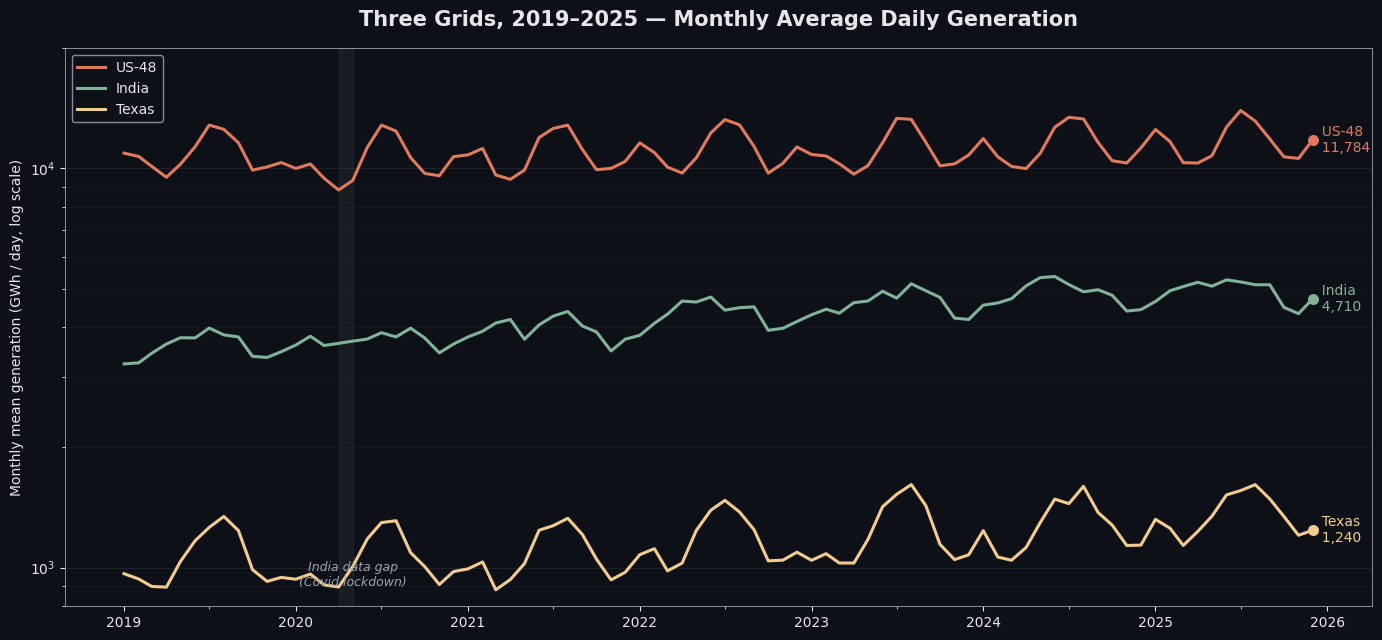

Saved ../art/three_grids_monthly_static.png


In [4]:
def style_ax(ax):
    ax.set_facecolor(BG)
    for sp in ax.spines.values():
        sp.set_color(MUTED)
        sp.set_linewidth(0.6)
    ax.tick_params(colors=FG, which='both')
    ax.yaxis.label.set_color(FG)
    ax.xaxis.label.set_color(FG)
    ax.title.set_color(FG)
    ax.grid(True, which='major', axis='y', color=MUTED, alpha=0.15, linewidth=0.6)
    ax.grid(True, which='minor', axis='y', color=MUTED, alpha=0.08, linewidth=0.5)

fig, ax = plt.subplots(figsize=(14, 6.5))
fig.patch.set_facecolor(BG)
style_ax(ax)

for region in ['US-48', 'India', 'Texas']:
    s = monthly_plot[region]
    ax.plot(s.index, s.values, color=COLORS[region], linewidth=2.2, label=region)
    # last-point marker
    ax.scatter(s.index[-1], s.values[-1], color=COLORS[region], s=48, zorder=5)
    ax.text(s.index[-1], s.values[-1], f'  {region}\n  {s.values[-1]:,.0f}',
            color=COLORS[region], fontsize=10, va='center')

# Mark any interpolated-gap ranges subtly
gap_mask = monthly['India'].isna()
if gap_mask.any():
    gap_months = monthly.index[gap_mask]
    ax.axvspan(gap_months.min(), gap_months.max(), color=COLORS['India'], alpha=0.08)
    mid = gap_months[len(gap_months)//2]
    ax.text(mid, 900, 'India data gap\n(Covid lockdown)',
            ha='center', color=MUTED, fontsize=9, style='italic')

ax.set_yscale('log')
ax.set_ylim(800, 20000)
ax.set_ylabel('Monthly mean generation (GWh / day, log scale)')
ax.set_title('Three Grids, 2019–2025 — Monthly Average Daily Generation',
             fontsize=15, fontweight='bold', pad=16)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator([1, 7]))

ax.legend(loc='upper left', facecolor=BG, edgecolor=MUTED, labelcolor=FG, framealpha=0.85)

out_png = OUT_ART / 'three_grids_monthly_static.png'
plt.tight_layout()
plt.savefig(out_png, dpi=140, facecolor=BG, bbox_inches='tight')
plt.show()
print(f'Saved {out_png}')

## 4. Animated version — growing lines across the year

84 frames (one per month, 2019-01 → 2025-12). Lines grow left-to-right; the current-frame tip of each line gets a dot marker. Title reports the month. 6 fps → 14 second runtime → easy to embed and watch.

Export as GIF via PillowWriter to match the Ed2 Texas animation style.

In [5]:
xs = monthly_plot.index
n_frames = len(xs)
print(f'Rendering {n_frames} frames...')

fig, ax = plt.subplots(figsize=(14, 6.5))
fig.patch.set_facecolor(BG)
style_ax(ax)

ax.set_yscale('log')
ax.set_ylim(800, 20000)
ax.set_xlim(xs[0], xs[-1])
ax.set_ylabel('Monthly mean generation (GWh / day, log scale)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator([1, 7]))

# One line + one dot marker per region
lines = {r: ax.plot([], [], color=COLORS[r], linewidth=2.2, label=r)[0] for r in monthly_plot.columns}
dots  = {r: ax.scatter([], [], color=COLORS[r], s=55, zorder=5) for r in monthly_plot.columns}
tags  = {r: ax.text(xs[0], monthly_plot[r].iloc[0], '', color=COLORS[r], fontsize=10, va='center')
         for r in monthly_plot.columns}

title = ax.text(0.02, 0.96, '', transform=ax.transAxes,
                color=FG, fontsize=15, fontweight='bold', va='top')
subtitle = ax.text(0.02, 0.91, 'Three Grids, 2019–2025 — Monthly Mean GWh/Day (log)',
                    transform=ax.transAxes, color=MUTED, fontsize=10, va='top')

ax.legend(loc='lower right', facecolor=BG, edgecolor=MUTED, labelcolor=FG, framealpha=0.85)

def update(frame):
    i = frame + 1
    current_date = xs[frame]
    title.set_text(current_date.strftime('%B %Y'))
    for r in monthly_plot.columns:
        y = monthly_plot[r].iloc[:i].values
        x = xs[:i]
        lines[r].set_data(x, y)
        if len(y) > 0 and not np.isnan(y[-1]):
            dots[r].set_offsets(np.column_stack([[mdates.date2num(xs[frame])], [y[-1]]]))
            tags[r].set_position((xs[frame], y[-1]))
            tags[r].set_text(f'  {r} {y[-1]:,.0f}')
    return list(lines.values()) + list(dots.values()) + list(tags.values()) + [title]

anim = FuncAnimation(fig, update, frames=n_frames, interval=1000/6, blit=False)

out_gif = OUT_ART / 'three_grids_monthly.gif'
anim.save(out_gif, writer=PillowWriter(fps=6), dpi=110)
plt.close(fig)
print(f'Saved {out_gif} ({out_gif.stat().st_size / 1e6:.2f} MB)')

Rendering 84 frames...


Saved ../art/three_grids_monthly.gif (1.59 MB)


## 5. Display inline

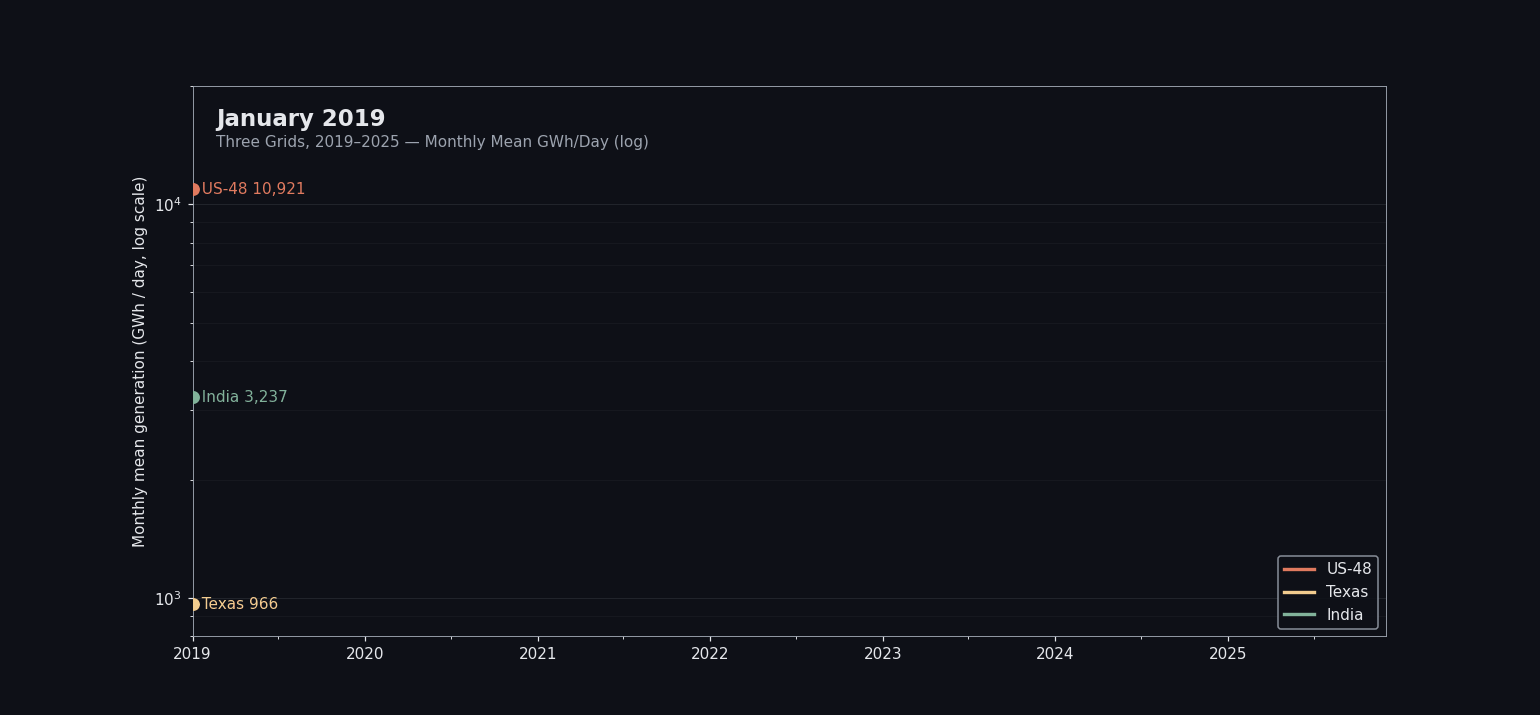

In [6]:
from IPython.display import Image, display
display(Image(filename=str(out_gif)))

## What the plot shows

1. **Log scale is essential.** On a linear axis Texas collapses to the floor — on log, the three lines read as three different growth stories.
2. **US is roughly flat** — 2019–2025 monthly mean oscillates around ~11,000–12,500 GWh/day with seasonal swings (summer AC + winter heating spike, spring trough). The US grid is mature; growth is marginal.
3. **India is climbing.** 2019 averaged ~3,600 GWh/day; 2025 averaged ~4,900 GWh/day — a ~35% rise over 6 years, driven by demand + electrification.
4. **Texas is climbing faster.** 2019 averaged ~1,100 GWh/day; 2025 averaged ~1,350 GWh/day — a ~23% rise, notably higher growth than US-wide.
5. **Seasonality signatures differ.** US has a wide seasonal amplitude (summer peak >15% above winter trough at US-wide); India and Texas both peak in summer too but with flatter shapes.
6. **2020 COVID dip** is visible in all three: US ≈ 3% below trend in Apr–May 2020, Texas similar, India deeper (~10%).

## Next

This is Part A of the three-grids bridge. Companion work: US-grid NB 06 (US-internal YoY) and the Ed2 US analytical arc (NBs 04–10) build on the same data.